In this notebook, the IMU data is smoothed by using rolling window mean and its impact is measured.
In the raw IMU data, spikes of the sensor values are observed in the sequence 09. The hypothesis is that removing the spikes of the IMU data resulting in smoothed IMU readings might affect on the prediction accracy. Hence the following setups are made:
- Collect all the filters result
- Collect the results of all filters, where IMU data is smoothed with the window size 5
- Collect the results of all filters, where IMU data is smoothed with the window size 10
- Compare the results.


In [33]:
import os
import sys
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
sys.path.append('/app/src')
from data_loader import DataLoader
from configs.configs import SetupEnum, ErrorEnum, FilterEnum, NoiseTypeEnum, MeasurementDataEnum
from kalman_filters import (
    ExtendedKalmanFilter,
    UnscentedKalmanFilter,
    ParticleFilter, ResamplingAlgorithms,
    EnsembleKalmanFilter,
    CubatureKalmanFilter
)
from utils.error_report import get_error_from_list


%matplotlib inline
np.random.seed(777)

In [2]:
class ExtendedDataLoader(DataLoader):

    def __init__(self):
        root_path = '../../../../'
        kitti_root_dir = os.path.join(root_path, "data")
        noise_vector_dir = os.path.join(root_path, "exports/_noise_optimizations/noise_vectors")
        kitti_drive = '0033'
        
        super().__init__(
            sequence_nr=kitti_drive, 
            kitti_root_dir=kitti_root_dir, 
            noise_vector_dir=noise_vector_dir,
            vo_dropout_ratio=0.0, 
            gps_dropout_ratio=0.0
        )
        self.change_smoothing_window_size(window_size=5)

    def change_smoothing_window_size(self, window_size):
        self.window_size = window_size
        
    def visualize_data_to_compare(self, imu_data, rolling_mean, labels):
        fig, ax = plt.subplots(3, 1, figsize=(10, 12))
        
        for idx in range(3):  
            i = idx + 4
            ax[idx].plot(self.ts, imu_data[:, idx:idx+1], lw=1, label='raw data', c="red")
            ax[idx].plot(self.ts, rolling_mean[:, idx:idx+1], lw=1, label='smoothed by rolling mean', c="blue")
            ax[idx].set_xlabel('time elapsed [sec]')
            ax[idx].set_ylabel(labels[idx])
            ax[idx].legend()
        fig.tight_layout()    
        
    # This function generates smoothed IMU data from raw IMU data, which consists of spikes and fluctuation, by applying rolling mean.
    def smooth_imu_data(self):
        linear_acc = self.IMU_outputs[:, :3].copy()
        angular_vel = self.IMU_outputs[:, 3:].copy()
        
        linear_acc_df = pd.DataFrame(linear_acc, columns=["acc_x", "acc_y", "acc_z"])
        ang_vel_df = pd.DataFrame(angular_vel, columns=["ang_vel_x", "ang_vel_y", "ang_vel_z"])
        
        linear_acc_rolling_mean = linear_acc_df.rolling(window=self.window_size).mean()
        angular_vel_rolling_mean = ang_vel_df.rolling(window=self.window_size).mean()
        
        loc_idx = self.window_size - 2
        np_idx = self.window_size - 1
        
        linear_acc_rolling_mean.loc[:loc_idx, "acc_x"] = linear_acc[:np_idx, 0]
        linear_acc_rolling_mean.loc[:loc_idx, "acc_y"] = linear_acc[:np_idx, 1]
        linear_acc_rolling_mean.loc[:loc_idx, "acc_z"] = linear_acc[:np_idx, 2]

        angular_vel_rolling_mean.loc[:loc_idx, "ang_vel_x"] = angular_vel[:np_idx, 0]
        angular_vel_rolling_mean.loc[:loc_idx, "ang_vel_y"] = angular_vel[:np_idx, 1]
        angular_vel_rolling_mean.loc[:loc_idx, "ang_vel_z"] = angular_vel[:np_idx, 2]
        

        ins_vel = self.INS_velocities.copy()
        ins_angle = self.INS_angles.copy()
        
        linear_vel_df = pd.DataFrame(ins_vel, columns=["vel_x", "vel_y", "vel_z"])
        ins_angle_df = pd.DataFrame(ins_angle, columns=["ang_x", "ang_y", "ang_z"])
        
        linear_vel_rolling_mean = linear_vel_df.rolling(window=self.window_size).mean()
        ins_angle_rolling_mean = ins_angle_df.rolling(window=self.window_size).mean()
        
        linear_vel_rolling_mean.loc[:loc_idx, "vel_x"] = ins_vel[:np_idx, 0]
        linear_vel_rolling_mean.loc[:loc_idx, "vel_y"] = ins_vel[:np_idx, 1]
        linear_vel_rolling_mean.loc[:loc_idx, "vel_z"] = ins_vel[:np_idx, 2]
        
        ins_angle_rolling_mean.loc[:loc_idx, "ang_x"] = ins_angle[:np_idx, 0]
        ins_angle_rolling_mean.loc[:loc_idx, "ang_y"] = ins_angle[:np_idx, 1]
        ins_angle_rolling_mean.loc[:loc_idx, "ang_z"] = ins_angle[:np_idx, 2]

        # Linear acceleration
        IMU_acc_noise = np.random.normal(0.0, self.IMU_acc_noise_std,(self.N_original, 3))  # gaussian noise
        self.IMU_acc_with_noise = linear_acc_rolling_mean.values
        self.IMU_acc_with_noise += IMU_acc_noise
        
        # angular velocity
        IMU_angular_velocity_noise = np.random.normal(0.0, self.IMU_angular_velocity_noise_std, (self.N_original,3))  # gen gaussian noise
        self.IMU_angular_velocity_with_noise = angular_vel_rolling_mean.values
        self.IMU_angular_velocity_with_noise += IMU_angular_velocity_noise  # add the noise to angular velocity as measurement noise


        # angular_rate = AngularRate(gyr=self.IMU_angular_velocity_with_noise)
        # self.IMU_quaternion = angular_rate.Q
        quaternions = [self.get_quaternion_from_euler_angle(angle) for angle in self.INS_angles]
        self.IMU_quaternion = np.array(quaternions)

        linear_velocity_noise = np.random.normal(0.0, self.velocity_noise_std, (self.N_original, 3))
        self.INS_velocities_with_noise = linear_vel_rolling_mean.values
        self.INS_velocities_with_noise += linear_velocity_noise

        angle_noise = np.random.normal(0.0, self.angle_noise_std, (self.N_original, 3))
        self.INS_angle_with_noise_original = ins_angle_rolling_mean.values
        self.INS_angle_with_noise_original += angle_noise


        if self.debug_mode:
            ang_y_labels = ['angualr velocity about x[rad/s]', 
                    'angualr velocity about y[rad/s]', 
                    'angualr velocity about z[rad/s]']
            
            self.visualize_data_to_compare(self.IMU_outputs[:, 3:], self.IMU_angular_velocity_with_noise, ang_y_labels)

            acc_y_labels = ['acceleration along x[m/s^2]', 
                    'acceleration along y[m/s^2]', 
                    'acceleration along z[m/s^2]']
            
            self.visualize_data_to_compare(self.IMU_outputs[:, :3], self.IMU_acc_with_noise, acc_y_labels)
    

Data size: 1591
Shape:
GPS: (1591, 3)
VO: (1591, 3)
IMU: (1591, 6)
INS angle: (1591, 3)
INS velocity: (1591, 3)
Add noise to GPS data
Adding noise to VO data
Adding noise to IMU sensor data
Adding noise to linear acceleration
Adding noise to angular velocity
Adding noise to INS sensor data
Adding noise to linear velocity data
Adding noise to angle data
Data sampling is set to normal mode.


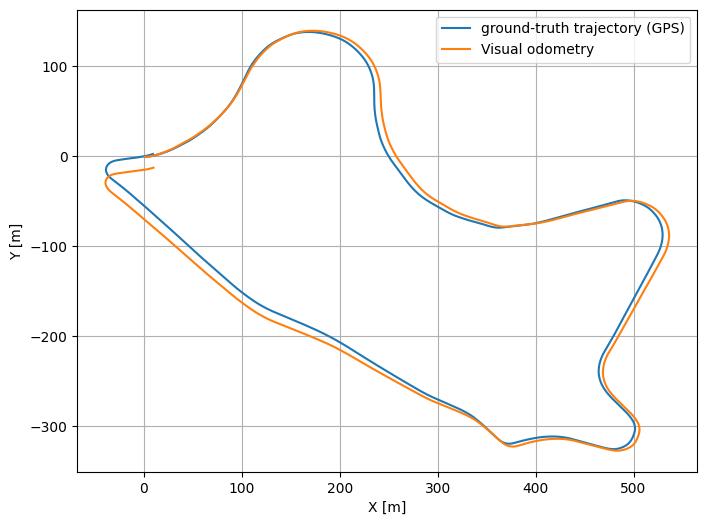

In [3]:
data = ExtendedDataLoader()

## Filter parameters

In [4]:
alpha_setup1_0 = 1.0
beta_setup1_0 = 2.0
kappa_setup1_0 = 0.0

alpha_setup2_0 = 0.6
beta_setup2_0 = 6.0
kappa_setup2_0 = 0.0

alpha_setup3_0 = 0.0001
beta_setup3_0 = 2.0
kappa_setup3_0 = 0.0

n_samples_setup1_0 = 2048
resampling_algorithm_setup1_0 = ResamplingAlgorithms.STRATIFIED
n_samples_setup2_0 = 2048
resampling_algorithm_setup2_0 = ResamplingAlgorithms.STRATIFIED
n_samples_setup3_0 = 2048
resampling_algorithm_setup3_0 = ResamplingAlgorithms.RESIDUAL

importance_resampling = True

n_ensemble_setup1_0 = 64
n_ensemble_setup2_0 = 64
n_ensemble_setup3_0 = 64

## Setup config

In [5]:
noise_type = NoiseTypeEnum.CURRENT
measurement_type = MeasurementDataEnum.ALL_DATA
debug_mode = True
show_graph = False

# Without smoothing IMU data

In [6]:
x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
    setup=SetupEnum.SETUP_1, 
    filter_type=FilterEnum.EKF,
    noise_type=noise_type
)
x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
    setup=SetupEnum.SETUP_2, 
    filter_type=FilterEnum.EKF, 
    noise_type=noise_type
)
x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
    setup=SetupEnum.SETUP_3, 
    filter_type=FilterEnum.EKF, 
    noise_type=noise_type
)
ekf1_0 = ExtendedKalmanFilter(
    x=x_setup1.copy(),
    P=P_setup1.copy(), 
    H=H_setup1.copy(),
    q=q1,
    r_vo=r_vo1,
    r_gps=r_gps1,
    setup=SetupEnum.SETUP_1)

ekf2_0 = ExtendedKalmanFilter(
    x=x_setup2.copy(), 
    P=P_setup2.copy(), 
    H=H_setup2.copy(),
    q=q2,
    r_vo=r_vo2,
    r_gps=r_gps2,
    setup=SetupEnum.SETUP_2)

ekf3_0 = ExtendedKalmanFilter(
    x=x_setup3.copy(), 
    P=P_setup3.copy(), 
    H=H_setup3.copy(),
    q=q3,
    r_vo=r_vo3,
    r_gps=r_gps3,
    setup=SetupEnum.SETUP_3)

error_ekf_1 = ekf1_0.run(data=data, debug_mode=debug_mode, show_graph=show_graph)
error_ekf_2 = ekf2_0.run(data=data, debug_mode=debug_mode, show_graph=show_graph)
error_ekf_3 = ekf3_0.run(data=data, debug_mode=debug_mode, show_graph=show_graph)

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
    setup=SetupEnum.SETUP_1, 
    filter_type=FilterEnum.UKF, 
    noise_type=noise_type
)
x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
    setup=SetupEnum.SETUP_2, 
    filter_type=FilterEnum.UKF, 
    noise_type=noise_type
)
x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
    setup=SetupEnum.SETUP_3, 
    filter_type=FilterEnum.UKF, 
    noise_type=noise_type
)
ukf1_0 = UnscentedKalmanFilter(
    x=x_setup1.copy(), 
    P=P_setup1.copy(), 
    H=H_setup1.copy(), 
    q=q1,
    r_vo=r_vo1,
    r_gps=r_gps1,
    alpha=alpha_setup1_0, 
    beta=beta_setup1_0, 
    kappa=kappa_setup1_0,
    setup=SetupEnum.SETUP_1)

ukf2_0 = UnscentedKalmanFilter(
    x=x_setup2.copy(), 
    P=P_setup2.copy(), 
    H=H_setup2.copy(), 
    q=q2,
    r_vo=r_vo2,
    r_gps=r_gps2,
    alpha=alpha_setup2_0, 
    beta=beta_setup2_0, 
    kappa=kappa_setup2_0,
    setup=SetupEnum.SETUP_2)

ukf3_0 = UnscentedKalmanFilter(
    x=x_setup3.copy(), 
    P=P_setup3.copy(), 
    H=H_setup3.copy(), 
    q=q3,
    r_vo=r_vo3,
    r_gps=r_gps3,
    alpha=alpha_setup3_0, 
    beta=beta_setup3_0, 
    kappa=kappa_setup3_0,
    setup=SetupEnum.SETUP_3)
error_ukf_1 = ukf1_0.run(data=data, debug_mode=debug_mode, show_graph=show_graph)
error_ukf_2 = ukf2_0.run(data=data, debug_mode=debug_mode, show_graph=show_graph)
error_ukf_3 = ukf3_0.run(data=data, debug_mode=debug_mode, show_graph=show_graph)

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
    setup=SetupEnum.SETUP_1, 
    filter_type=FilterEnum.PF, 
    noise_type=noise_type
)
x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
    setup=SetupEnum.SETUP_2, 
    filter_type=FilterEnum.PF, 
    noise_type=noise_type
)
x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
    setup=SetupEnum.SETUP_3, 
    filter_type=FilterEnum.PF, 
    noise_type=noise_type
)

pf1_0 = ParticleFilter(
    N=n_samples_setup1_0, 
    x_dim=x_setup1.shape[0], 
    H=H_setup1.copy(), 
    q=q1,
    r_vo=r_vo1,
    r_gps=r_gps1,
    setup=SetupEnum.SETUP_1,
    resampling_algorithm=resampling_algorithm_setup1_0
)
pf1_0.create_gaussian_particles(mean=x_setup1.copy(), var=P_setup1.copy())

pf2_0 = ParticleFilter(
    N=n_samples_setup2_0, 
    x_dim=x_setup2.shape[0], 
    H=H_setup2.copy(), 
    q=q2,
    r_vo=r_vo2,
    r_gps=r_gps2,
    setup=SetupEnum.SETUP_2,
    resampling_algorithm=resampling_algorithm_setup2_0
)
pf2_0.create_gaussian_particles(mean=x_setup2.copy(), var=P_setup2.copy())

pf3_0 = ParticleFilter(
    N=n_samples_setup3_0, 
    x_dim=x_setup3.shape[0], 
    H=H_setup3.copy(), 
    q=q3,
    r_vo=r_vo3,
    r_gps=r_gps3,
    setup=SetupEnum.SETUP_3,
    resampling_algorithm=resampling_algorithm_setup3_0
)
pf3_0.create_gaussian_particles(mean=x_setup3.copy(), var=P_setup3.copy())

error_pf_1 = pf1_0.run(data=data, importance_resampling=importance_resampling, debug_mode=debug_mode, show_graph=show_graph)
error_pf_2 = pf2_0.run(data=data, importance_resampling=importance_resampling, debug_mode=debug_mode, show_graph=show_graph)
error_pf_3 = pf3_0.run(data=data, importance_resampling=importance_resampling, debug_mode=debug_mode, show_graph=show_graph)


x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
    setup=SetupEnum.SETUP_1, 
    filter_type=FilterEnum.EnKF, 
    noise_type=noise_type
)
x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
    setup=SetupEnum.SETUP_2, 
    filter_type=FilterEnum.EnKF, 
    noise_type=noise_type
)
x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
    setup=SetupEnum.SETUP_3, 
    filter_type=FilterEnum.EnKF, 
    noise_type=noise_type
)

enkf1_0 = EnsembleKalmanFilter(        
    N=n_ensemble_setup1_0, 
    x=x_setup1.copy(), 
    P=P_setup1.copy(), 
    H=H_setup1.copy(),
    q=q1,
    r_vo=r_vo1,
    r_gps=r_gps1,
    setup=SetupEnum.SETUP_1
)
enkf2_0 = EnsembleKalmanFilter(
    N=n_ensemble_setup2_0, 
    x=x_setup2.copy(), 
    P=P_setup2.copy(), 
    H=H_setup2.copy(),
    q=q2,
    r_vo=r_vo2,
    r_gps=r_gps2,
    setup=SetupEnum.SETUP_2
)
enkf3_0 = EnsembleKalmanFilter(
    N=n_ensemble_setup3_0, 
    x=x_setup3.copy(), 
    P=P_setup3.copy(), 
    H=H_setup3.copy(),
    q=q3,
    r_vo=r_vo3,
    r_gps=r_gps3,
    setup=SetupEnum.SETUP_3
)

error_enkf_1 = enkf1_0.run(data=data, debug_mode=debug_mode, show_graph=show_graph)
error_enkf_2 = enkf2_0.run(data=data, debug_mode=debug_mode, show_graph=show_graph)
error_enkf_3 = enkf3_0.run(data=data, debug_mode=debug_mode, show_graph=show_graph)

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
    setup=SetupEnum.SETUP_1, 
    filter_type=FilterEnum.CKF, 
    noise_type=noise_type
)
x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
    setup=SetupEnum.SETUP_2, 
    filter_type=FilterEnum.CKF, 
    noise_type=noise_type
)
x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
    setup=SetupEnum.SETUP_3, 
    filter_type=FilterEnum.CKF, 
    noise_type=noise_type
)

ckf1_0 = CubatureKalmanFilter(
    x=x_setup1.copy(), 
    P=P_setup1.copy(), 
    H=H_setup1.copy(),
    q=q1,
    r_vo=r_vo1,
    r_gps=r_gps1,
    setup=SetupEnum.SETUP_1
)
ckf2_0 = CubatureKalmanFilter(
    x=x_setup2.copy(), 
    P=P_setup2.copy(), 
    H=H_setup2.copy(),
    q=q2,
    r_vo=r_vo2,
    r_gps=r_gps2,
    setup=SetupEnum.SETUP_2
)
ckf3_0 = CubatureKalmanFilter( 
    x=x_setup3.copy(), 
    P=P_setup3.copy(), 
    H=H_setup3.copy(),
    q=q3,
    r_vo=r_vo3,
    r_gps=r_gps3,
    setup=SetupEnum.SETUP_3
)
error_ckf_1 = ckf1_0.run(data=data, debug_mode=debug_mode, show_graph=show_graph)
error_ckf_2 = ckf2_0.run(data=data, debug_mode=debug_mode, show_graph=show_graph)
error_ckf_3 = ckf3_0.run(data=data, debug_mode=debug_mode, show_graph=show_graph)

error_current_1 = [error_ekf_1, error_ukf_1, error_pf_1, error_enkf_1, error_ckf_1]
error_current_2 = [error_ekf_2, error_ukf_2, error_pf_2, error_enkf_2, error_ckf_2]
error_current_3 = [error_ekf_3, error_ukf_3, error_pf_3, error_enkf_3, error_ckf_3]

[EKF] start.


100%|█████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 12930.95it/s]



----- [EKF] Error report for Setup1 (IMU, VO) -----
Mean Absolute Error: 3.904 m
Root Mean Squared Error: 5.486 m
Maximum Error: 16.056 m
---------------------------------------------------

[EKF] start.


100%|█████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 10624.11it/s]



----- [EKF] Error report for Setup2 (IMU, VO+GPS) -----
Mean Absolute Error: 1.99 m
Root Mean Squared Error: 2.762 m
Maximum Error: 8.483 m
-------------------------------------------------------

[EKF] start.


...


----- [CKF] Error report for Setup1 (IMU, VO) -----
Mean Absolute Error: 3.955 m
Root Mean Squared Error: 5.522 m
Maximum Error: 16.221 m
---------------------------------------------------

[CKF] start.


100%|██████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 2169.61it/s]



----- [CKF] Error report for Setup2 (IMU, VO+GPS) -----
Mean Absolute Error: 1.462 m
Root Mean Squared Error: 1.967 m
Maximum Error: 6.375 m
-------------------------------------------------------

[CKF] start.


100%|██████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 7152.94it/s]


----- [CKF] Error report for Setup3 (INS) -----
Mean Absolute Error: 1.55 m
Root Mean Squared Error: 2.099 m
Maximum Error: 6.745 m
-----------------------------------------------



# Smoothed IMU sensor data

## window_size = 5

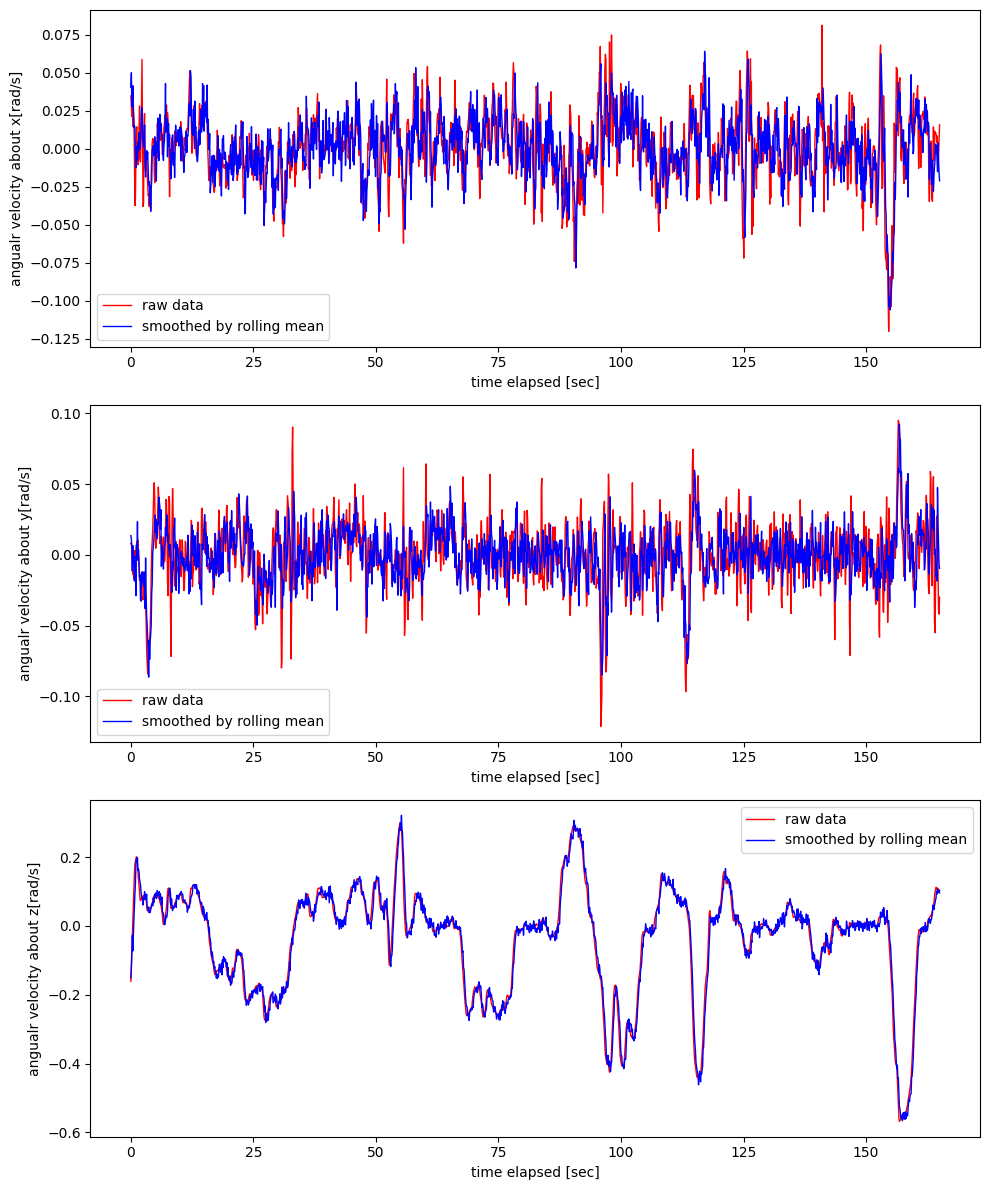

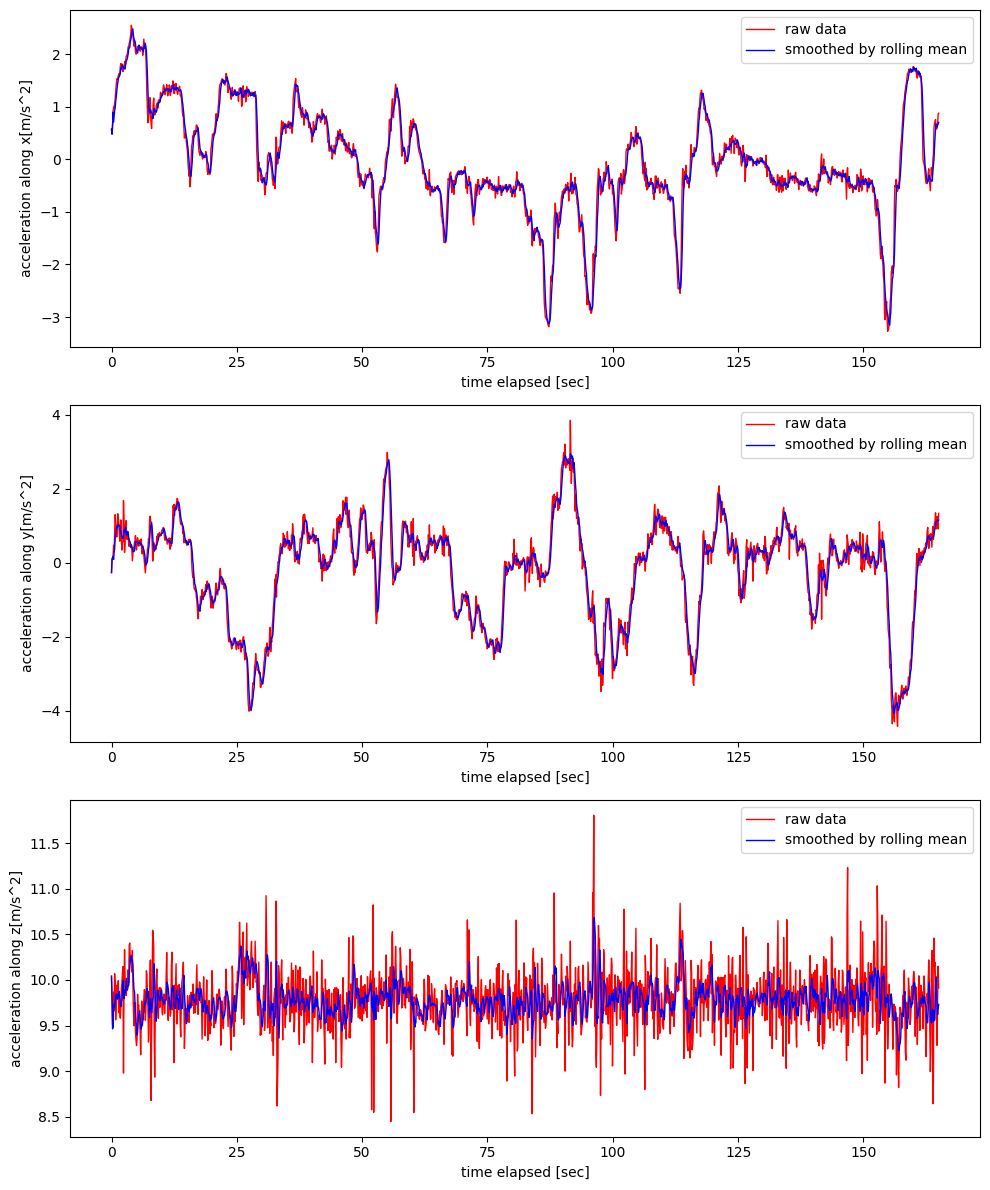

In [7]:
data.change_smoothing_window_size(window_size=5)
data.smooth_imu_data()

In [8]:
x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
    setup=SetupEnum.SETUP_1, 
    filter_type=FilterEnum.EKF,
    noise_type=noise_type
)
x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
    setup=SetupEnum.SETUP_2, 
    filter_type=FilterEnum.EKF, 
    noise_type=noise_type
)
x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
    setup=SetupEnum.SETUP_3, 
    filter_type=FilterEnum.EKF, 
    noise_type=noise_type
)
ekf1_5 = ExtendedKalmanFilter(
    x=x_setup1.copy(),
    P=P_setup1.copy(), 
    H=H_setup1.copy(),
    q=q1,
    r_vo=r_vo1,
    r_gps=r_gps1,
    setup=SetupEnum.SETUP_1)

ekf2_5 = ExtendedKalmanFilter(
    x=x_setup2.copy(), 
    P=P_setup2.copy(), 
    H=H_setup2.copy(),
    q=q2,
    r_vo=r_vo2,
    r_gps=r_gps2,
    setup=SetupEnum.SETUP_2)

ekf3_5 = ExtendedKalmanFilter(
    x=x_setup3.copy(), 
    P=P_setup3.copy(), 
    H=H_setup3.copy(),
    q=q3,
    r_vo=r_vo3,
    r_gps=r_gps3,
    setup=SetupEnum.SETUP_3)


error_ekf_1_5 = ekf1_5.run(data=data, debug_mode=debug_mode, show_graph=show_graph)
error_ekf_2_5 = ekf2_5.run(data=data, debug_mode=debug_mode, show_graph=show_graph)
error_ekf_3_5 = ekf3_5.run(data=data, debug_mode=debug_mode, show_graph=show_graph)



x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
    setup=SetupEnum.SETUP_1, 
    filter_type=FilterEnum.UKF, 
    noise_type=noise_type
)
x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
    setup=SetupEnum.SETUP_2, 
    filter_type=FilterEnum.UKF, 
    noise_type=noise_type
)
x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
    setup=SetupEnum.SETUP_3, 
    filter_type=FilterEnum.UKF, 
    noise_type=noise_type
)

ukf1_5 = UnscentedKalmanFilter(
    x=x_setup1.copy(), 
    P=P_setup1.copy(), 
    H=H_setup1.copy(), 
    q=q1,
    r_vo=r_vo1,
    r_gps=r_gps1,
    alpha=alpha_setup1_0, 
    beta=beta_setup1_0, 
    kappa=kappa_setup1_0,
    setup=SetupEnum.SETUP_1)

ukf2_5 = UnscentedKalmanFilter(
    x=x_setup2.copy(), 
    P=P_setup2.copy(), 
    H=H_setup2.copy(), 
    q=q2,
    r_vo=r_vo2,
    r_gps=r_gps2,
    alpha=alpha_setup2_0, 
    beta=beta_setup2_0, 
    kappa=kappa_setup2_0,
    setup=SetupEnum.SETUP_2)

ukf3_5 = UnscentedKalmanFilter(
    x=x_setup3.copy(), 
    P=P_setup3.copy(), 
    H=H_setup3.copy(), 
    q=q3,
    r_vo=r_vo3,
    r_gps=r_gps3,
    alpha=alpha_setup3_0, 
    beta=beta_setup3_0, 
    kappa=kappa_setup3_0,
    setup=SetupEnum.SETUP_3)

error_ukf_1_5 = ukf1_5.run(data=data, debug_mode=debug_mode, show_graph=show_graph)
error_ukf_2_5 = ukf2_5.run(data=data, debug_mode=debug_mode, show_graph=show_graph)
error_ukf_3_5 = ukf3_5.run(data=data, debug_mode=debug_mode, show_graph=show_graph)



x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
    setup=SetupEnum.SETUP_1, 
    filter_type=FilterEnum.PF, 
    noise_type=noise_type
)
x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
    setup=SetupEnum.SETUP_2, 
    filter_type=FilterEnum.PF, 
    noise_type=noise_type
)
x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
    setup=SetupEnum.SETUP_3, 
    filter_type=FilterEnum.PF, 
    noise_type=noise_type
)
pf1_5 = ParticleFilter(
    N=n_samples_setup1_0, 
    x_dim=x_setup1.shape[0], 
    H=H_setup1.copy(), 
    q=q1,
    r_vo=r_vo1,
    r_gps=r_gps1,
    setup=SetupEnum.SETUP_1,
    resampling_algorithm=resampling_algorithm_setup1_0)

pf1_5.create_gaussian_particles(mean=x_setup1.copy(), var=P_setup1.copy())

pf2_5 = ParticleFilter(
    N=n_samples_setup2_0, 
    x_dim=x_setup2.shape[0], 
    H=H_setup2.copy(), 
    q=q2,
    r_vo=r_vo2,
    r_gps=r_gps2,
    setup=SetupEnum.SETUP_2,
    resampling_algorithm=resampling_algorithm_setup2_0)

pf2_5.create_gaussian_particles(mean=x_setup2.copy(), var=P_setup2.copy())

pf3_5 = ParticleFilter(
    N=n_samples_setup3_0, 
    x_dim=x_setup3.shape[0], 
    H=H_setup3.copy(), 
    q=q3,
    r_vo=r_vo3,
    r_gps=r_gps3,
    setup=SetupEnum.SETUP_3,
    resampling_algorithm=resampling_algorithm_setup3_0)

pf3_5.create_gaussian_particles(mean=x_setup3.copy(), var=P_setup3.copy())

error_pf_1_5 = pf1_5.run(data=data, importance_resampling=importance_resampling, debug_mode=debug_mode, show_graph=show_graph)
error_pf_2_5 = pf2_5.run(data=data, importance_resampling=importance_resampling, debug_mode=debug_mode, show_graph=show_graph)
error_pf_3_5 = pf3_5.run(data=data, importance_resampling=importance_resampling, debug_mode=debug_mode, show_graph=show_graph)


x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
    setup=SetupEnum.SETUP_1, 
    filter_type=FilterEnum.EnKF, 
    noise_type=noise_type
)
x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
    setup=SetupEnum.SETUP_2, 
    filter_type=FilterEnum.EnKF, 
    noise_type=noise_type
)
x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
    setup=SetupEnum.SETUP_3, 
    filter_type=FilterEnum.EnKF, 
    noise_type=noise_type
)

enkf1_5 = EnsembleKalmanFilter(        
    N=n_ensemble_setup1_0, 
    x=x_setup1.copy(), 
    P=P_setup1.copy(), 
    H=H_setup1.copy(),
    q=q1,
    r_vo=r_vo1,
    r_gps=r_gps1,
    setup=SetupEnum.SETUP_1)
enkf2_5 = EnsembleKalmanFilter(
    N=n_ensemble_setup2_0, 
    x=x_setup2.copy(), 
    P=P_setup2.copy(), 
    H=H_setup2.copy(),
    q=q2,
    r_vo=r_vo2,
    r_gps=r_gps2,
    setup=SetupEnum.SETUP_2)

enkf3_5 = EnsembleKalmanFilter(
    N=n_ensemble_setup3_0, 
    x=x_setup3.copy(), 
    P=P_setup3.copy(), 
    H=H_setup3.copy(),
    q=q3,
    r_vo=r_vo3,
    r_gps=r_gps3,
    setup=SetupEnum.SETUP_3)

error_enkf_1_5 = enkf1_5.run(data=data, debug_mode=debug_mode, show_graph=show_graph)
error_enkf_2_5 = enkf2_5.run(data=data, debug_mode=debug_mode, show_graph=show_graph)
error_enkf_3_5 = enkf3_5.run(data=data, debug_mode=debug_mode, show_graph=show_graph)



x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
    setup=SetupEnum.SETUP_1, 
    filter_type=FilterEnum.CKF, 
    noise_type=noise_type
)
x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
    setup=SetupEnum.SETUP_2, 
    filter_type=FilterEnum.CKF, 
    noise_type=noise_type
)
x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
    setup=SetupEnum.SETUP_3, 
    filter_type=FilterEnum.CKF, 
    noise_type=noise_type
)

ckf1_5 = CubatureKalmanFilter(
    x=x_setup1.copy(), 
    P=P_setup1.copy(), 
    H=H_setup1.copy(),
    q=q1,
    r_vo=r_vo1,
    r_gps=r_gps1,
    setup=SetupEnum.SETUP_1)

ckf2_5 = CubatureKalmanFilter(
    x=x_setup2.copy(), 
    P=P_setup2.copy(), 
    H=H_setup2.copy(),
    q=q2,
    r_vo=r_vo2,
    r_gps=r_gps2,
    setup=SetupEnum.SETUP_2)

ckf3_5 = CubatureKalmanFilter( 
    x=x_setup3.copy(), 
    P=P_setup3.copy(), 
    H=H_setup3.copy(),
    q=q3,
    r_vo=r_vo3,
    r_gps=r_gps3,
    setup=SetupEnum.SETUP_3)


error_ckf_1_5 = ckf1_5.run(data=data, debug_mode=debug_mode, show_graph=show_graph)
error_ckf_2_5 = ckf2_5.run(data=data, debug_mode=debug_mode, show_graph=show_graph)
error_ckf_3_5 = ckf3_5.run(data=data, debug_mode=debug_mode, show_graph=show_graph)


error_1_smoothed_5 = [error_ekf_1_5, error_ukf_1_5, error_pf_1_5, error_enkf_1_5, error_ckf_1_5]
error_2_smoothed_5 = [error_ekf_2_5, error_ukf_2_5, error_pf_2_5, error_enkf_2_5, error_ckf_2_5]
error_3_smoothed_5 = [error_ekf_3_5, error_ukf_3_5, error_pf_3_5, error_enkf_3_5, error_ckf_3_5]

[EKF] start.


100%|█████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 12785.53it/s]



----- [EKF] Error report for Setup1 (IMU, VO) -----
Mean Absolute Error: 3.904 m
Root Mean Squared Error: 5.486 m
Maximum Error: 16.041 m
---------------------------------------------------

[EKF] start.


100%|█████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 10745.72it/s]



----- [EKF] Error report for Setup2 (IMU, VO+GPS) -----
Mean Absolute Error: 1.99 m
Root Mean Squared Error: 2.762 m
Maximum Error: 8.477 m
-------------------------------------------------------

[EKF] start.


...


----- [CKF] Error report for Setup1 (IMU, VO) -----
Mean Absolute Error: 3.92 m
Root Mean Squared Error: 5.495 m
Maximum Error: 16.542 m
---------------------------------------------------

[CKF] start.


100%|██████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 2130.64it/s]



----- [CKF] Error report for Setup2 (IMU, VO+GPS) -----
Mean Absolute Error: 1.462 m
Root Mean Squared Error: 1.967 m
Maximum Error: 6.374 m
-------------------------------------------------------

[CKF] start.


100%|██████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 7100.22it/s]


----- [CKF] Error report for Setup3 (INS) -----
Mean Absolute Error: 1.55 m
Root Mean Squared Error: 2.098 m
Maximum Error: 6.761 m
-----------------------------------------------



## window_size = 10

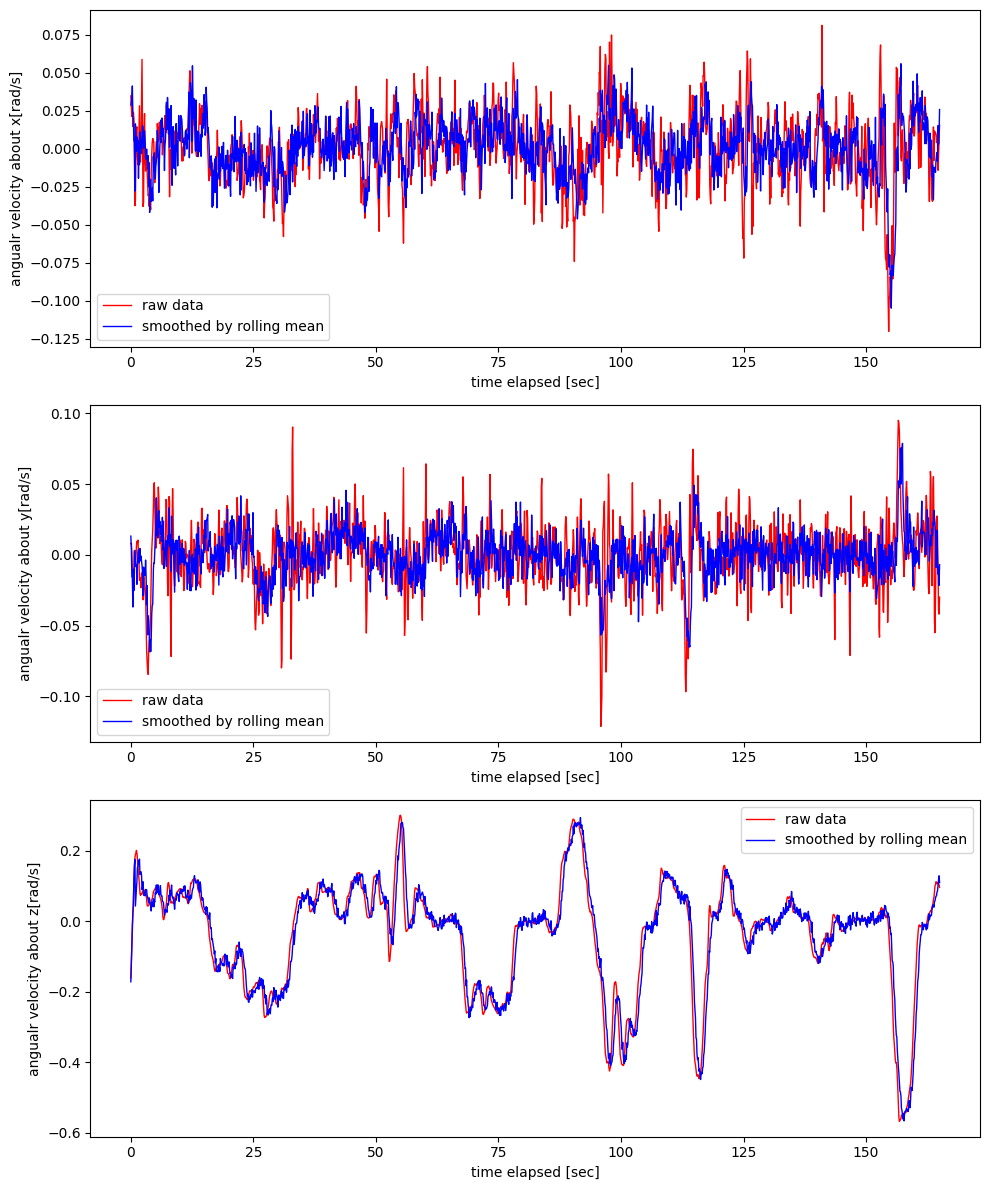

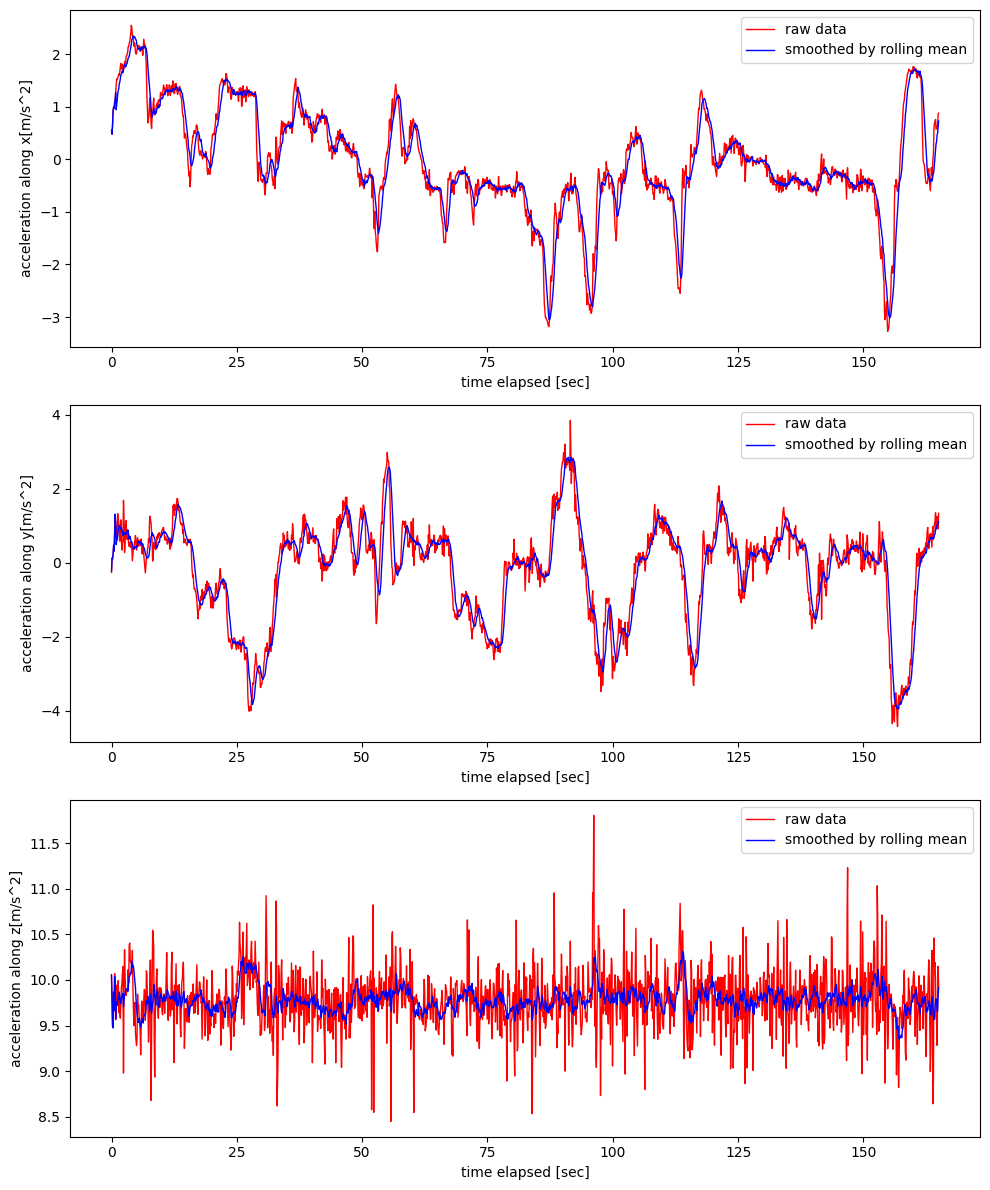

In [9]:
data.change_smoothing_window_size(window_size=10)
data.smooth_imu_data()

In [10]:
x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
    setup=SetupEnum.SETUP_1, 
    filter_type=FilterEnum.EKF,
    noise_type=noise_type
)
x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
    setup=SetupEnum.SETUP_2, 
    filter_type=FilterEnum.EKF, 
    noise_type=noise_type
)
x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
    setup=SetupEnum.SETUP_3, 
    filter_type=FilterEnum.EKF, 
    noise_type=noise_type
)
ekf1_10 = ExtendedKalmanFilter(
    x=x_setup1.copy(),
    P=P_setup1.copy(), 
    H=H_setup1.copy(),
    q=q1,
    r_vo=r_vo1,
    r_gps=r_gps1,
    setup=SetupEnum.SETUP_1)

ekf2_10 = ExtendedKalmanFilter(
    x=x_setup2.copy(), 
    P=P_setup2.copy(), 
    H=H_setup2.copy(),
    q=q2,
    r_vo=r_vo2,
    r_gps=r_gps2,
    setup=SetupEnum.SETUP_2)

ekf3_10 = ExtendedKalmanFilter(
    x=x_setup3.copy(), 
    P=P_setup3.copy(), 
    H=H_setup3.copy(),
    q=q3,
    r_vo=r_vo3,
    r_gps=r_gps3,
    setup=SetupEnum.SETUP_3)


error_ekf_1_10 = ekf1_10.run(data=data, debug_mode=debug_mode, show_graph=show_graph)
error_ekf_2_10 = ekf2_10.run(data=data, debug_mode=debug_mode, show_graph=show_graph)
error_ekf_3_10 = ekf3_10.run(data=data, debug_mode=debug_mode, show_graph=show_graph)



x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
    setup=SetupEnum.SETUP_1, 
    filter_type=FilterEnum.UKF,
    noise_type=noise_type
)
x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
    setup=SetupEnum.SETUP_2, 
    filter_type=FilterEnum.UKF, 
    noise_type=noise_type
)
x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
    setup=SetupEnum.SETUP_3, 
    filter_type=FilterEnum.UKF, 
    noise_type=noise_type
)
ukf1_10 = UnscentedKalmanFilter(
    x=x_setup1.copy(), 
    P=P_setup1.copy(), 
    H=H_setup1.copy(), 
    q=q1,
    r_vo=r_vo1,
    r_gps=r_gps1,
    alpha=alpha_setup1_0, 
    beta=beta_setup1_0, 
    kappa=kappa_setup1_0,
    setup=SetupEnum.SETUP_1)

ukf2_10 = UnscentedKalmanFilter(
    x=x_setup2.copy(), 
    P=P_setup2.copy(), 
    H=H_setup2.copy(), 
    q=q2,
    r_vo=r_vo2,
    r_gps=r_gps2,
    alpha=alpha_setup2_0, 
    beta=beta_setup2_0, 
    kappa=kappa_setup2_0,
    setup=SetupEnum.SETUP_2)

ukf3_10 = UnscentedKalmanFilter(
    x=x_setup3.copy(), 
    P=P_setup3.copy(), 
    H=H_setup3.copy(), 
    q=q3,
    r_vo=r_vo3,
    r_gps=r_gps3,
    alpha=alpha_setup3_0, 
    beta=beta_setup3_0, 
    kappa=kappa_setup3_0,
    setup=SetupEnum.SETUP_3)

error_ukf_1_10 = ukf1_10.run(data=data, debug_mode=debug_mode, show_graph=show_graph)
error_ukf_2_10 = ukf2_10.run(data=data, debug_mode=debug_mode, show_graph=show_graph)
error_ukf_3_10 = ukf3_10.run(data=data, debug_mode=debug_mode, show_graph=show_graph)



x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
    setup=SetupEnum.SETUP_1, 
    filter_type=FilterEnum.PF,
    noise_type=noise_type
)
x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
    setup=SetupEnum.SETUP_2, 
    filter_type=FilterEnum.PF, 
    noise_type=noise_type
)
x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
    setup=SetupEnum.SETUP_3, 
    filter_type=FilterEnum.PF, 
    noise_type=noise_type
)
pf1_10 = ParticleFilter(
    N=n_samples_setup1_0, 
    x_dim=x_setup1.shape[0], 
    H=H_setup1.copy(), 
    q=q1,
    r_vo=r_vo1,
    r_gps=r_gps1,
    setup=SetupEnum.SETUP_1,
    resampling_algorithm=resampling_algorithm_setup1_0)

pf1_10.create_gaussian_particles(mean=x_setup1.copy(), var=P_setup1.copy())

pf2_10 = ParticleFilter(
    N=n_samples_setup2_0, 
    x_dim=x_setup2.shape[0], 
    H=H_setup2.copy(), 
    q=q2,
    r_vo=r_vo2,
    r_gps=r_gps2,
    setup=SetupEnum.SETUP_2,
    resampling_algorithm=resampling_algorithm_setup2_0)

pf2_10.create_gaussian_particles(mean=x_setup2.copy(), var=P_setup2.copy())

pf3_10 = ParticleFilter(
    N=n_samples_setup3_0, 
    x_dim=x_setup3.shape[0], 
    H=H_setup3.copy(), 
    q=q3,
    r_vo=r_vo3,
    r_gps=r_gps3,
    setup=SetupEnum.SETUP_3,
    resampling_algorithm=resampling_algorithm_setup3_0)

pf3_10.create_gaussian_particles(mean=x_setup3.copy(), var=P_setup3.copy())

error_pf_1_10 = pf1_10.run(data=data, importance_resampling=importance_resampling, debug_mode=debug_mode, show_graph=show_graph)
error_pf_2_10 = pf2_10.run(data=data, importance_resampling=importance_resampling, debug_mode=debug_mode, show_graph=show_graph)
error_pf_3_10 = pf3_10.run(data=data, importance_resampling=importance_resampling, debug_mode=debug_mode, show_graph=show_graph)


x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
    setup=SetupEnum.SETUP_1, 
    filter_type=FilterEnum.EnKF,
    noise_type=noise_type
)
x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
    setup=SetupEnum.SETUP_2, 
    filter_type=FilterEnum.EnKF, 
    noise_type=noise_type
)
x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
    setup=SetupEnum.SETUP_3, 
    filter_type=FilterEnum.EnKF, 
    noise_type=noise_type
)
enkf1_10 = EnsembleKalmanFilter(        
    N=n_ensemble_setup1_0, 
    x=x_setup1.copy(), 
    P=P_setup1.copy(), 
    H=H_setup1.copy(),
    q=q1,
    r_vo=r_vo1,
    r_gps=r_gps1,
    setup=SetupEnum.SETUP_1)
enkf2_10 = EnsembleKalmanFilter(
    N=n_ensemble_setup2_0, 
    x=x_setup2.copy(), 
    P=P_setup2.copy(), 
    H=H_setup2.copy(),
    q=q2,
    r_vo=r_vo2,
    r_gps=r_gps2,
    setup=SetupEnum.SETUP_2)

enkf3_10 = EnsembleKalmanFilter(
    N=n_ensemble_setup3_0, 
    x=x_setup3.copy(), 
    P=P_setup3.copy(), 
    H=H_setup3.copy(),
    q=q3,
    r_vo=r_vo3,
    r_gps=r_gps3,
    setup=SetupEnum.SETUP_3)

error_enkf_1_10 = enkf1_10.run(data=data, debug_mode=debug_mode, show_graph=show_graph)
error_enkf_2_10 = enkf2_10.run(data=data, debug_mode=debug_mode, show_graph=show_graph)
error_enkf_3_10 = enkf3_10.run(data=data, debug_mode=debug_mode, show_graph=show_graph)



x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
    setup=SetupEnum.SETUP_1, 
    filter_type=FilterEnum.CKF,
    noise_type=noise_type
)
x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
    setup=SetupEnum.SETUP_2, 
    filter_type=FilterEnum.CKF, 
    noise_type=noise_type
)
x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
    setup=SetupEnum.SETUP_3, 
    filter_type=FilterEnum.CKF, 
    noise_type=noise_type
)
ckf1_10 = CubatureKalmanFilter(
    x=x_setup1.copy(), 
    P=P_setup1.copy(), 
    H=H_setup1.copy(),
    q=q1,
    r_vo=r_vo1,
    r_gps=r_gps1,
    setup=SetupEnum.SETUP_1)

ckf2_10 = CubatureKalmanFilter(
    x=x_setup2.copy(), 
    P=P_setup2.copy(), 
    H=H_setup2.copy(),
    q=q2,
    r_vo=r_vo2,
    r_gps=r_gps2,
    setup=SetupEnum.SETUP_2)

ckf3_10 = CubatureKalmanFilter( 
    x=x_setup3.copy(), 
    P=P_setup3.copy(), 
    H=H_setup3.copy(),
    q=q3,
    r_vo=r_vo3,
    r_gps=r_gps3,
    setup=SetupEnum.SETUP_3)


error_ckf_1_10 = ckf1_10.run(data=data, debug_mode=debug_mode, show_graph=show_graph)
error_ckf_2_10 = ckf2_10.run(data=data, debug_mode=debug_mode, show_graph=show_graph)
error_ckf_3_10 = ckf3_10.run(data=data, debug_mode=debug_mode, show_graph=show_graph)


error_1_smoothed_10 = [error_ekf_1_10, error_ukf_1_10, error_pf_1_10, error_enkf_1_10, error_ckf_1_10]
error_2_smoothed_10 = [error_ekf_2_10, error_ukf_2_10, error_pf_2_10, error_enkf_2_10, error_ckf_2_10]
error_3_smoothed_10 = [error_ekf_3_10, error_ukf_3_10, error_pf_3_10, error_enkf_3_10, error_ckf_3_10]

[EKF] start.


100%|█████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 13087.39it/s]



----- [EKF] Error report for Setup1 (IMU, VO) -----
Mean Absolute Error: 3.904 m
Root Mean Squared Error: 5.486 m
Maximum Error: 16.037 m
---------------------------------------------------

[EKF] start.


100%|█████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 10965.95it/s]



----- [EKF] Error report for Setup2 (IMU, VO+GPS) -----
Mean Absolute Error: 1.991 m
Root Mean Squared Error: 2.763 m
Maximum Error: 8.464 m
-------------------------------------------------------

[EKF] start.


...


----- [CKF] Error report for Setup1 (IMU, VO) -----
Mean Absolute Error: 3.983 m
Root Mean Squared Error: 5.544 m
Maximum Error: 16.226 m
---------------------------------------------------

[CKF] start.


100%|██████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 2184.34it/s]



----- [CKF] Error report for Setup2 (IMU, VO+GPS) -----
Mean Absolute Error: 1.462 m
Root Mean Squared Error: 1.966 m
Maximum Error: 6.371 m
-------------------------------------------------------

[CKF] start.


100%|██████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 7052.02it/s]


----- [CKF] Error report for Setup3 (INS) -----
Mean Absolute Error: 1.55 m
Root Mean Squared Error: 2.096 m
Maximum Error: 6.766 m
-----------------------------------------------



# Result

## Computing results

In [18]:
header = pd.MultiIndex.from_product([["Setup1 (IMU, VO)", "Setup2 (IMU, VO + GPS)", "Setup3 (INS, VO + GPS)"],
                               ["MAE", "RMSE", "MAX"]],
                               names=['Setups', 'Error types'])
df_index = ["EKF", "UKF", "PF", "EnKF", "CKF"]

def create_error_df(setup1_error, setup2_error, setup3_error):
    setup1_mae = np.array(get_error_from_list(setup1_error, ErrorEnum.MAE)).reshape(-1, 1)
    setup1_rmse = np.array(get_error_from_list(setup1_error, ErrorEnum.RMSE)).reshape(-1, 1)
    setup1_max = np.array(get_error_from_list(setup1_error, ErrorEnum.MAX)).reshape(-1, 1)
    
    setup1_error = np.concatenate([
        setup1_mae, 
        setup1_rmse,
        setup1_max
    ], axis=1)
    
    setup2_mae = np.array(get_error_from_list(setup2_error, ErrorEnum.MAE)).reshape(-1, 1)
    setup2_rmse = np.array(get_error_from_list(setup2_error, ErrorEnum.RMSE)).reshape(-1, 1)
    setup2_max = np.array(get_error_from_list(setup2_error, ErrorEnum.MAX)).reshape(-1, 1)
    
    setup2_error = np.concatenate([
        setup2_mae, 
        setup2_rmse,
        setup2_max
    ], axis=1)

    setup3_mae = np.array(get_error_from_list(setup3_error, ErrorEnum.MAE)).reshape(-1, 1)
    setup3_rmse = np.array(get_error_from_list(setup3_error, ErrorEnum.RMSE)).reshape(-1, 1)
    setup3_max = np.array(get_error_from_list(setup3_error, ErrorEnum.MAX)).reshape(-1, 1)
    
    setup3_error = np.concatenate([
        setup3_mae, 
        setup3_rmse,
        setup3_max
    ], axis=1)

    error = np.concatenate([
        setup1_error, 
        setup2_error,
        setup3_error
    ], axis=1)
    
    return pd.DataFrame(
        error, 
        columns=header,
        index=df_index
    )

In [ ]:
setup1_wo_imu = [error_wo_imu_ekf1, error_wo_imu_ukf1, error_wo_imu_pf1, error_wo_imu_enkf1, error_wo_imu_ckf1]
setup2_wo_imu = [error_wo_imu_ekf2, error_wo_imu_ukf2, error_wo_imu_pf2, error_wo_imu_enkf2, error_wo_imu_ckf2]
setup3_wo_imu = [error_wo_imu_ekf3, error_wo_imu_ukf3, error_wo_imu_pf3, error_wo_imu_enkf3, error_wo_imu_ckf3]

setup1_w_5_imu = [error_w_imu_ekf1, error_w_imu_ukf1, error_w_imu_pf1, error_w_imu_enkf1, error_w_imu_ckf1]
setup2_w_5_imu = [error_w_imu_ekf2, error_w_imu_ukf2, error_w_imu_pf2, error_w_imu_enkf2, error_w_imu_ckf2]
setup3_w_5_imu = [error_w_imu_ekf3, error_w_imu_ukf3, error_w_imu_pf3, error_w_imu_enkf3, error_w_imu_ckf3]

In [22]:
error_df_without_smoothed_imu = create_error_df(
    setup1_error=error_current_1, 
    setup2_error=error_current_2, 
    setup3_error=error_current_3
)
error_df_with_smoothed_imu_5 = create_error_df(
    setup1_error=error_1_smoothed_5, 
    setup2_error=error_2_smoothed_5, 
    setup3_error=error_3_smoothed_5
)
error_df_with_smoothed_imu_10 = create_error_df(
    setup1_error=error_1_smoothed_10, 
    setup2_error=error_2_smoothed_10, 
    setup3_error=error_3_smoothed_10
)

In [24]:
error_delta_without_imu_and_with_imu_5 = error_df_without_smoothed_imu - error_df_with_smoothed_imu_5
error_delta_without_imu_and_with_imu_10 = error_df_without_smoothed_imu - error_df_with_smoothed_imu_10

## Comparison

### Estimation error without IMU smoothing

In [28]:
error_df_without_smoothed_imu

Estimation error without IMU smoothing


Setups      Setup1 (IMU, VO)                Setup2 (IMU, VO + GPS)         \
Error types              MAE   RMSE     MAX                    MAE   RMSE   
EKF                    3.904  5.486  16.056                  1.990  2.762   
UKF                    4.170  5.682  16.566                  2.871  3.708   
PF                     3.912  5.497  16.312                  0.558  0.703   
EnKF                   4.060  5.616  19.190                  2.300  3.219   
CKF                    3.955  5.522  16.221                  1.462  1.967   

Setups              Setup3 (INS, VO + GPS)                
Error types     MAX                    MAE   RMSE    MAX  
EKF           8.483                  1.948  2.737  8.202  
UKF          14.044                  1.569  2.139  6.770  
PF            3.098                  0.430  0.557  2.323  
EnKF         29.581                  1.106  1.403  5.279  
CKF           6.375                  1.550  2.099  6.745

### Estimation error with IMU smoothing (window size=5)

In [26]:
error_df_with_smoothed_imu_5

Setups      Setup1 (IMU, VO)                Setup2 (IMU, VO + GPS)         \
Error types              MAE   RMSE     MAX                    MAE   RMSE   
EKF                    3.904  5.486  16.041                  1.990  2.762   
UKF                    4.362  5.904  18.469                  2.854  3.539   
PF                     3.927  5.499  16.849                  0.553  0.698   
EnKF                   4.063  5.612  19.939                  2.180  3.068   
CKF                    3.920  5.495  16.542                  1.462  1.967   

Setups              Setup3 (INS, VO + GPS)                
Error types     MAX                    MAE   RMSE    MAX  
EKF           8.477                  1.952  2.736  8.266  
UKF          12.371                  1.571  2.142  6.809  
PF            3.064                  0.444  0.570  2.307  
EnKF         22.483                  1.116  1.413  6.182  
CKF           6.374                  1.550  2.098  6.761

### Estimation error with IMU smoothing (window size=10)

In [27]:
error_df_with_smoothed_imu_10

Setups      Setup1 (IMU, VO)                Setup2 (IMU, VO + GPS)         \
Error types              MAE   RMSE     MAX                    MAE   RMSE   
EKF                    3.904  5.486  16.037                  1.991  2.763   
UKF                    3.880  5.277  16.048                  2.812  3.563   
PF                     3.910  5.485  16.156                  0.553  0.697   
EnKF                   4.076  5.620  18.309                  2.313  3.203   
CKF                    3.983  5.544  16.226                  1.462  1.966   

Setups              Setup3 (INS, VO + GPS)                
Error types     MAX                    MAE   RMSE    MAX  
EKF           8.464                  1.959  2.733  8.369  
UKF          12.251                  1.569  2.137  6.766  
PF            3.338                  0.464  0.595  2.438  
EnKF         17.973                  1.117  1.415  5.439  
CKF           6.371                  1.550  2.096  6.766

### Differences between estimation errors, with IMU smoothing (window size=5) and without IMU smoothing

In [29]:
error_delta_without_imu_and_with_imu_5

Setups      Setup1 (IMU, VO)               Setup2 (IMU, VO + GPS)         \
Error types              MAE   RMSE    MAX                    MAE   RMSE   
EKF                    0.000  0.000  0.015                  0.000  0.000   
UKF                   -0.192 -0.222 -1.903                  0.017  0.169   
PF                    -0.015 -0.002 -0.537                  0.005  0.005   
EnKF                  -0.003  0.004 -0.749                  0.120  0.151   
CKF                    0.035  0.027 -0.321                  0.000  0.000   

Setups             Setup3 (INS, VO + GPS)                
Error types    MAX                    MAE   RMSE    MAX  
EKF          0.006                 -0.004  0.001 -0.064  
UKF          1.673                 -0.002 -0.003 -0.039  
PF           0.034                 -0.014 -0.013  0.016  
EnKF         7.098                 -0.010 -0.010 -0.903  
CKF          0.001                  0.000  0.001 -0.016

### Differences between estimation errors, with IMU smoothing (window size=10) and without IMU smoothing

In [30]:
error_delta_without_imu_and_with_imu_10

Setups      Setup1 (IMU, VO)               Setup2 (IMU, VO + GPS)         \
Error types              MAE   RMSE    MAX                    MAE   RMSE   
EKF                    0.000  0.000  0.019                 -0.001 -0.001   
UKF                    0.290  0.405  0.518                  0.059  0.145   
PF                     0.002  0.012  0.156                  0.005  0.006   
EnKF                  -0.016 -0.004  0.881                 -0.013  0.016   
CKF                   -0.028 -0.022 -0.005                  0.000  0.001   

Setups              Setup3 (INS, VO + GPS)                
Error types     MAX                    MAE   RMSE    MAX  
EKF           0.019                 -0.011  0.004 -0.167  
UKF           1.793                  0.000  0.002  0.004  
PF           -0.240                 -0.034 -0.038 -0.115  
EnKF         11.608                 -0.011 -0.012 -0.160  
CKF           0.004                  0.000  0.003 -0.021

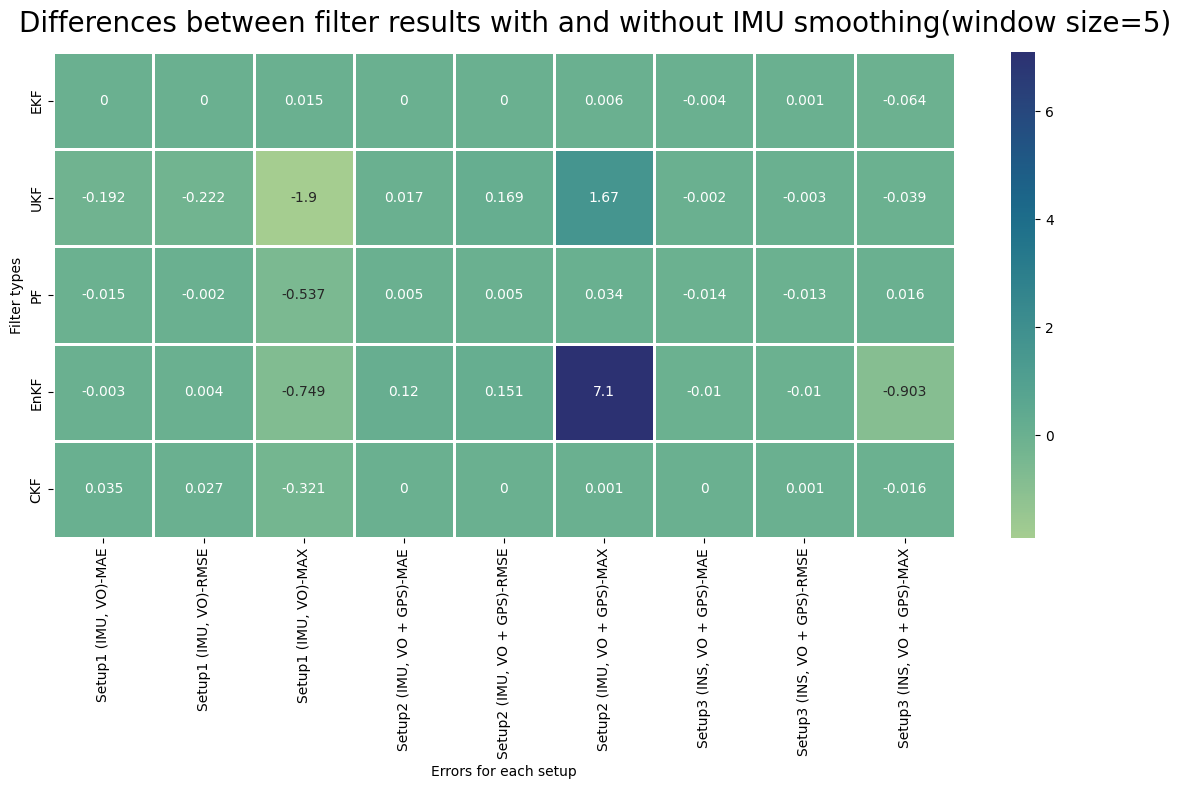

In [36]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(12, 8))
fig.suptitle("Differences between filter results with and without IMU smoothing(window size=5)", fontsize=20)
sns.heatmap(error_delta_without_imu_and_with_imu_5,
            ax=ax,
            cmap="crest",
            annot=True,
            linewidths=1,
            fmt='.3g')
ax.set(xlabel="Errors for each setup", ylabel="Filter types")
ax.tick_params(axis='x', rotation=90)


fig.tight_layout()

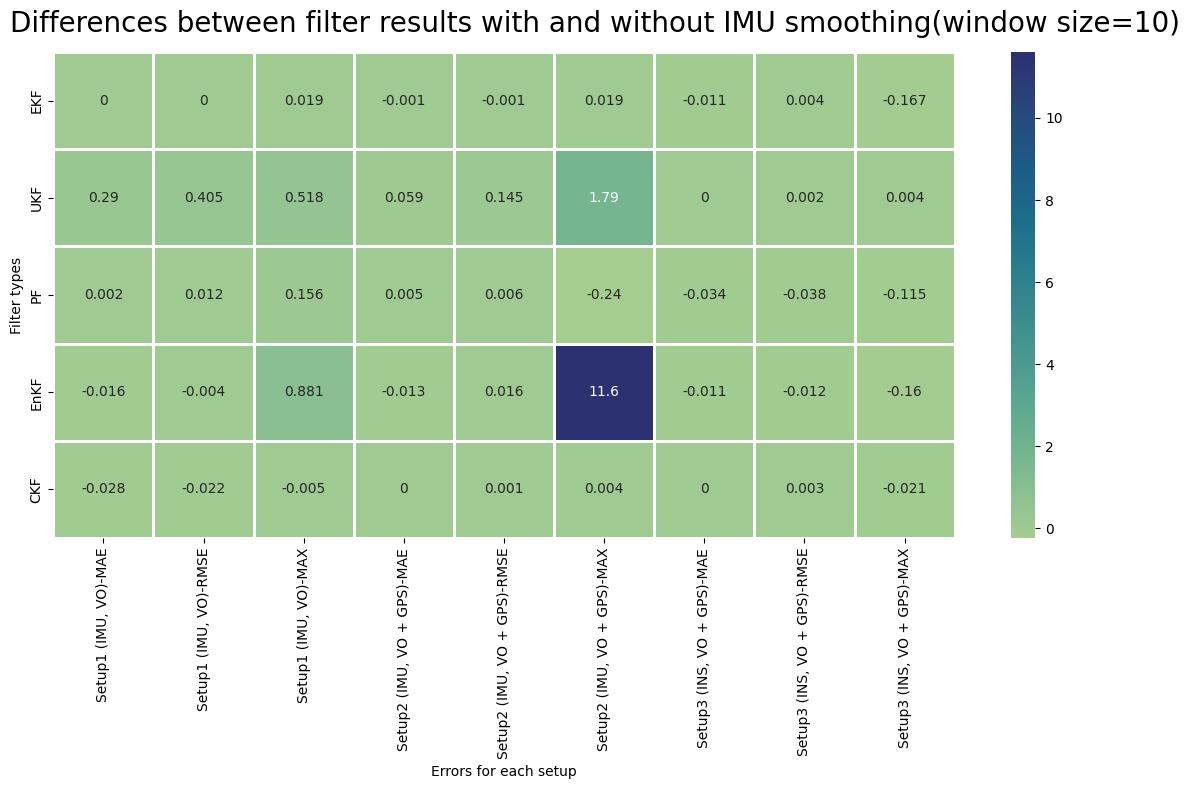

In [37]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(12, 8))
fig.suptitle("Differences between filter results with and without IMU smoothing(window size=10)", fontsize=20)
sns.heatmap(error_delta_without_imu_and_with_imu_10,
            ax=ax,
            cmap="crest",
            annot=True,
            linewidths=1,
            fmt='.3g')
ax.set(xlabel="Errors for each setup", ylabel="Filter types")
ax.tick_params(axis='x', rotation=90)


fig.tight_layout()

## Analysis

The heatmap above shows that the difference between filter results with and without IMU data smoothing computed by $error_{without IMU smoothing} - error_{with IMU smoothing (window size=x)}$, where positive value indicates without IMU smoothing has more error meaning that IMU smoothing improves the result of estimations while negative value indicates that smoothed IMU brings negative impact on the estimations.

The result shows that althgough there are some improvement experienced in EnKF maximum errors, the two metrics, MAE and RMSE, show no significant improvement, where negative and positive values exist at the same time meaning that some filters have improved result when IMU data is smoothed and some filters result in worse estimation when IMU smoothed data.



# Conclusion

From the experiment, the estimation error with smoothed IMU data does not experience a significant improvement. Therefore, we can conclude that smoothing the IMU data does not affect on the filter accuracy.